In [6]:
from itertools import chain

import anndata as ad
import itertools
import networkx as nx
import pandas as pd
import scanpy as sc
import scglue
import seaborn as sns
from matplotlib import rcParams

In [ ]:
rna = ad.read_h5ad("/Users/ahura/Documents/3rd_year_project/code/03_scglue/scglue_model_data/rna-pp.h5ad")
atac = ad.read_h5ad("/Users/ahura/Documents/3rd_year_project/code/03_scglue/scglue_model_data/atac-pp.h5ad")
guidance = nx.read_graphml("/Users/ahura/Documents/3rd_year_project/code/03_scglue/scglue_model_data/guidance.graphml")

In [15]:
rna

AnnData object with n_obs × n_vars = 3129 × 36390
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'Neurotypical reference', 'Class', 'Subclass', 'Supertype', 'Age at death', 'Years of education', 'Cognitive status', 'ADNC', 'Braak stage', 'Thal phase', 'CERAD score', 'APOE4 status', 'Lewy body disease pathology', 'LATE-NC stage', 'Microinfarct pathology', 'Specimen ID', 'donor_id', 'PMI', 'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs', 'suspension_type', 'development_stage_ontology_term_id', 'Continuous Pseudo-progression Score', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', '

In [14]:
rna.layers

Layers with keys: counts

In [3]:
scglue.models.configure_dataset(
    rna, "NB", use_highly_variable=False,
    use_layer="counts", use_rep="X_pca",
    use_obs_names = True
    
)

In [4]:
scglue.models.configure_dataset(
    atac, "NB", use_highly_variable=False,
    use_rep="X_lsi", use_obs_names = True
)

In [5]:
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    atac.var.query("highly_variable").index
)).copy()

In [ ]:
len(guidance_hvf.edges())

In [6]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "atac": atac}, guidance,
    model = scglue.models.PairedSCGLUEModel,
    fit_kws={
        "directory":"glue",
        "max_epochs":100
    }
    
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using CPU as computation device.
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!
[INFO] PairedSCGLUEModel: Setting `graph_batch_size` = 260520
[INFO] PairedSCGLUEModel: Setting `patience` = 91
[INFO] PairedSCGLUEModel: Setting `reduce_lr_patience` = 46
[INFO] PairedSCGLUETrainer: Using training directory: "glue/pretrain"


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_e

[INFO] PairedSCGLUETrainer: [Epoch 10] train={'g_nll': 0.608, 'g_kl': 0.0, 'g_elbo': 0.608, 'x_rna_nll': 0.243, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.245, 'x_atac_nll': 0.128, 'x_atac_kl': 0.0, 'x_atac_elbo': 0.128, 'dsc_loss': 0.692, 'vae_loss': 0.414, 'gen_loss': 0.379, 'joint_cross_loss': 0.366, 'real_cross_loss': 0.37, 'cos_loss': 0.073}, val={'g_nll': 0.609, 'g_kl': 0.0, 'g_elbo': 0.609, 'x_rna_nll': 0.256, 'x_rna_kl': 0.003, 'x_rna_elbo': 0.259, 'x_atac_nll': 0.124, 'x_atac_kl': 0.0, 'x_atac_elbo': 0.124, 'dsc_loss': 0.684, 'vae_loss': 0.424, 'gen_loss': 0.389, 'joint_cross_loss': 0.369, 'real_cross_loss': 0.368, 'cos_loss': 0.063}, 96.8s elapsed


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_e

[INFO] PairedSCGLUETrainer: [Epoch 20] train={'g_nll': 0.556, 'g_kl': 0.0, 'g_elbo': 0.556, 'x_rna_nll': 0.235, 'x_rna_kl': 0.003, 'x_rna_elbo': 0.238, 'x_atac_nll': 0.125, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.126, 'dsc_loss': 0.691, 'vae_loss': 0.401, 'gen_loss': 0.367, 'joint_cross_loss': 0.359, 'real_cross_loss': 0.364, 'cos_loss': 0.038}, val={'g_nll': 0.554, 'g_kl': 0.0, 'g_elbo': 0.555, 'x_rna_nll': 0.233, 'x_rna_kl': 0.003, 'x_rna_elbo': 0.236, 'x_atac_nll': 0.12, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.12, 'dsc_loss': 0.691, 'vae_loss': 0.393, 'gen_loss': 0.359, 'joint_cross_loss': 0.353, 'real_cross_loss': 0.355, 'cos_loss': 0.024}, 74.0s elapsed


...

[INFO] PairedSCGLUETrainer: [Epoch 80] train={'g_nll': 0.406, 'g_kl': 0.001, 'g_elbo': 0.406, 'x_rna_nll': 0.223, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.225, 'x_atac_nll': 0.113, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.114, 'dsc_loss': 0.691, 'vae_loss': 0.369, 'gen_loss': 0.335, 'joint_cross_loss': 0.337, 'real_cross_loss': 0.341, 'cos_loss': 0.034}, val={'g_nll': 0.405, 'g_kl': 0.001, 'g_elbo': 0.405, 'x_rna_nll': 0.225, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.227, 'x_atac_nll': 0.11, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.11, 'dsc_loss': 0.687, 'vae_loss': 0.368, 'gen_loss': 0.334, 'joint_cross_loss': 0.335, 'real_cross_loss': 0.339, 'cos_loss': 0.034}, 68.6s elapsed


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_e

[INFO] PairedSCGLUETrainer: [Epoch 90] train={'g_nll': 0.405, 'g_kl': 0.001, 'g_elbo': 0.405, 'x_rna_nll': 0.223, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.225, 'x_atac_nll': 0.113, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.113, 'dsc_loss': 0.691, 'vae_loss': 0.369, 'gen_loss': 0.334, 'joint_cross_loss': 0.336, 'real_cross_loss': 0.34, 'cos_loss': 0.035}, val={'g_nll': 0.404, 'g_kl': 0.001, 'g_elbo': 0.405, 'x_rna_nll': 0.226, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.228, 'x_atac_nll': 0.11, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.11, 'dsc_loss': 0.691, 'vae_loss': 0.369, 'gen_loss': 0.334, 'joint_cross_loss': 0.336, 'real_cross_loss': 0.34, 'cos_loss': 0.036}, 68.8s elapsed


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_e

[INFO] PairedSCGLUETrainer: [Epoch 100] train={'g_nll': 0.404, 'g_kl': 0.001, 'g_elbo': 0.404, 'x_rna_nll': 0.222, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.225, 'x_atac_nll': 0.113, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.113, 'dsc_loss': 0.692, 'vae_loss': 0.369, 'gen_loss': 0.334, 'joint_cross_loss': 0.336, 'real_cross_loss': 0.34, 'cos_loss': 0.035}, val={'g_nll': 0.404, 'g_kl': 0.001, 'g_elbo': 0.404, 'x_rna_nll': 0.226, 'x_rna_kl': 0.002, 'x_rna_elbo': 0.229, 'x_atac_nll': 0.109, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.109, 'dsc_loss': 0.689, 'vae_loss': 0.368, 'gen_loss': 0.334, 'joint_cross_loss': 0.336, 'real_cross_loss': 0.34, 'cos_loss': 0.036}, 75.9s elapsed
[INFO] EarlyStopping: No usable checkpoint found. Skipping checkpoint restoration.


In [7]:
glue.save("glue.dill")
# glue = scglue.models.load_model("glue.dill")

In [8]:
dx = scglue.models.integration_consistency(
    glue, {"rna": rna, "atac": atac}, guidance_hvf
)
dx

[INFO] integration_consistency: Using layer "counts" for modality "rna"
[INFO] integration_consistency: Selecting aggregation "sum" for modality "rna"
[INFO] integration_consistency: Selecting aggregation "sum" for modality "atac"
[INFO] integration_consistency: Selecting log-norm preprocessing for modality "rna"
[INFO] integration_consistency: Selecting log-norm preprocessing for modality "atac"
[INFO] get_metacells: Clustering metacells...


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecate

[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 10 common metacells...


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/scglue/data.py:671: RuntimeWarning: invalid value encountered in scalar divide
  ((X[s] * X[t]).mean() - mean[s] * mean[t]) / (std[s] * std[t])


[INFO] get_metacells: Clustering metacells...


...

[INFO] get_metacells: Clustering metacells...


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
[WARNING] get_metacells: `faiss` is not installed, using `sklearn` instead... This might be slow with a large number of cells. Consider installing `faiss` following the guide from https://github.com/facebookresearch/faiss/blob/main/INSTALL.md


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 171 common metacells...


/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/scglue_env/lib/python3.10/site-packages/scglue/data.py:671: RuntimeWarning: invalid value encountered in scalar divide
  ((X[s] * X[t]).mean() - mean[s] * mean[t]) / (std[s] * std[t])


,n_meta,consistency
0,10,0.121649
1,20,0.083772
2,50,0.055952
3,100,0.032937
4,200,0.011079


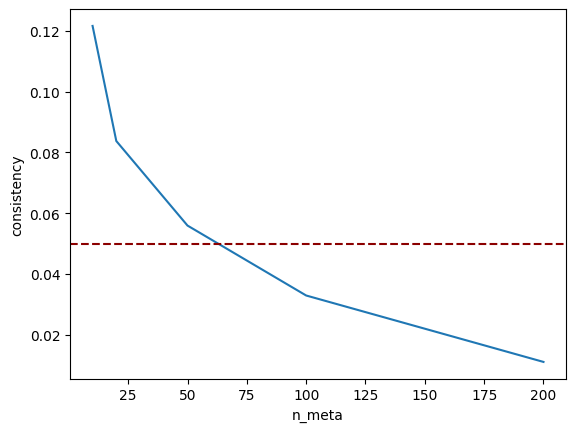

In [9]:
_ = sns.lineplot(x="n_meta", y="consistency", data=dx).axhline(y=0.05, c="darkred", ls="--")